In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
plt.style.use("dark_background")

# U-MAP Cluster

In [3]:
!pip install umap-learn
!pip install hdbscan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 63.5 MB/s eta 0:00:00


In [4]:
import umap.umap_ as umap
import hdbscan
from sklearn.preprocessing import StandardScaler

2025-04-14 14:49:18.382222: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744642158.590408      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744642158.655631      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Explainability Model 1

In [5]:
X = pd.read_csv("/kaggle/input/snn-m3-data/Model1.2_Out/test_dfs0.csv")
X["customer_age"] = 0
y_pred = pd.read_csv("/kaggle/input/snn-m3-data/Model1.2_Out/predictions_run0.csv", header=None)
y_true = X["fraud_bool"]
X = X.drop("fraud_bool", axis=1)

In [6]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(X)

umap_model = umap.UMAP(n_neighbors=5, random_state=42, verbose=True)#, metric="correlation")
X_umap = umap_model.fit_transform(data_scaled)

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(n_jobs=1, n_neighbors=5, random_state=42, verbose=True)
Mon Apr 14 14:49:43 2025 Construct fuzzy simplicial set
Mon Apr 14 14:49:43 2025 Finding Nearest Neighbors
Mon Apr 14 14:49:43 2025 Building RP forest with 28 trees
Mon Apr 14 14:49:57 2025 NN descent for 18 iterations
	 1  /  18
	 2  /  18
	 3  /  18
	 4  /  18
	Stopping threshold met -- exiting after 4 iterations
Mon Apr 14 14:50:19 2025 Finished Nearest Neighbor Search
Mon Apr 14 14:50:22 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Apr 14 14:52:34 2025 Finished embedding


In [7]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=100)
clusters = clusterer.fit_predict(X_umap)

result_df = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2'])
result_df['Cluster'] = clusters
result_df['Prediction'] = y_pred.values.flatten()
result_df['Label'] = y_true.values.flatten()

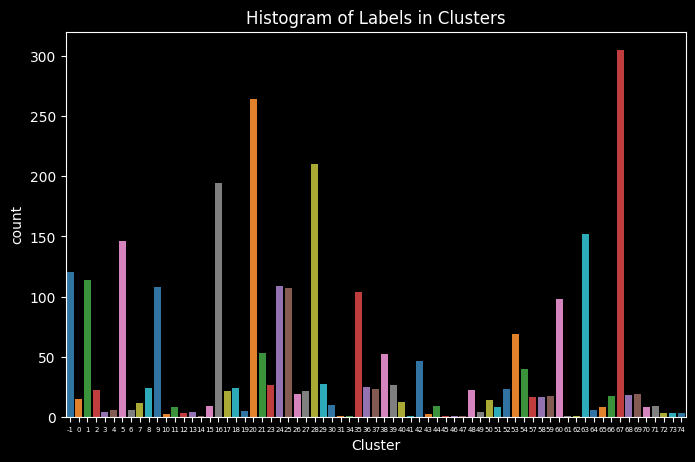

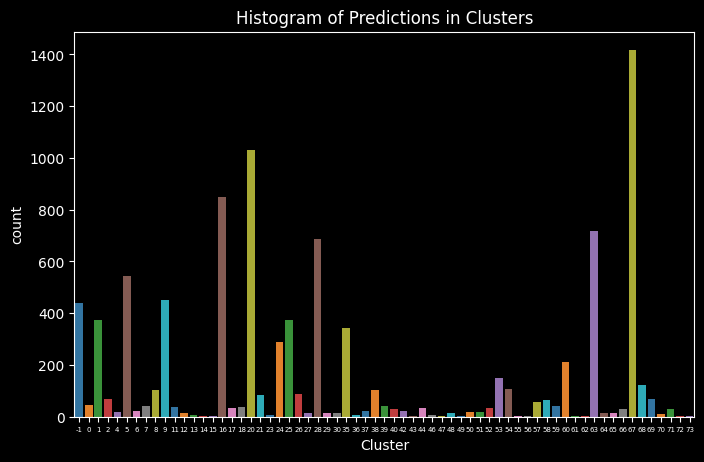

In [8]:
positive_preds = result_df[result_df['Label'] == 1]
plt.figure(figsize=(8, 5))
plt.xticks(fontsize=5)
sns.countplot(data=positive_preds, x='Cluster', palette='tab10')
plt.title('Histogram of Labels in Clusters')
plt.show()

positive_preds = result_df[result_df['Prediction'] == 1]
plt.figure(figsize=(8, 5))
plt.xticks(fontsize=5)
sns.countplot(data=positive_preds, x='Cluster', palette='tab10')
plt.title('Histogram of Predictions in Clusters')
plt.show()

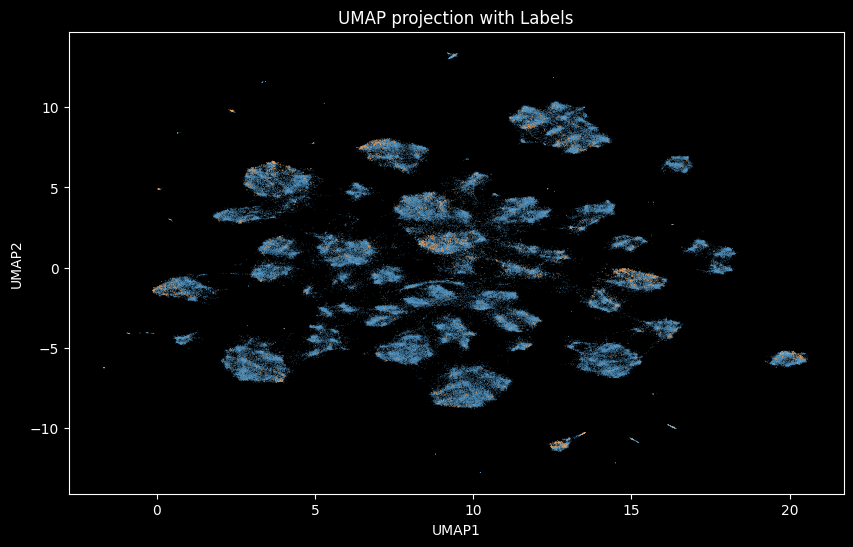

In [9]:
plt.figure(figsize=(10, 6))

palette = sns.color_palette('tab10', n_colors=result_df['Label'].nunique())
label_colors = {label: palette[i] for i, label in enumerate(sorted(result_df['Label'].unique()))}

sns.scatterplot(
    data=result_df[result_df['Label'] != 1],
    x='UMAP1', y='UMAP2',
    hue='Label',
    palette=label_colors,
    s=0.1,
    legend=False,
    zorder=1
)

sns.scatterplot(
    data=result_df[result_df['Label'] == 1],
    x='UMAP1', y='UMAP2',
    hue='Label',
    palette=label_colors,
    s=0.3,
    legend=False,
    zorder=2
)

plt.title('UMAP projection with Labels')
plt.show()

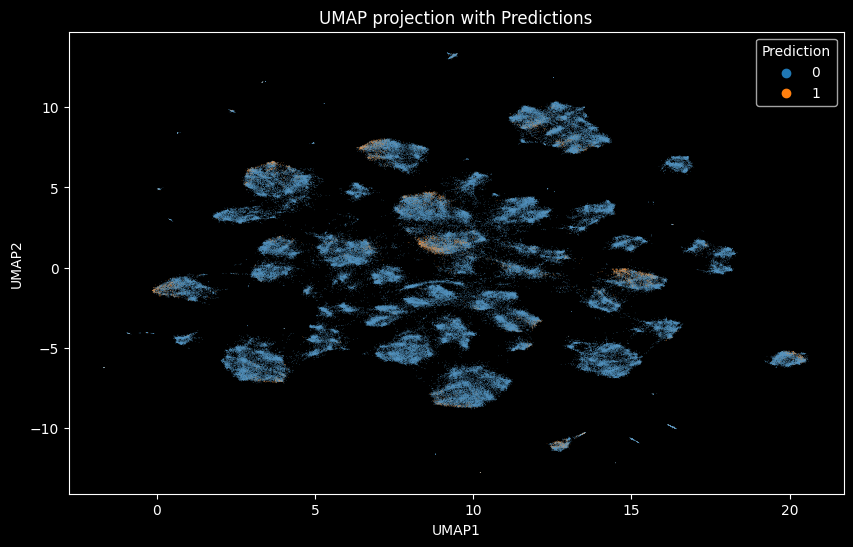

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=result_df, x='UMAP1', y='UMAP2', hue='Prediction', palette='tab10', s=0.1)
plt.title('UMAP projection with Predictions')
plt.show()

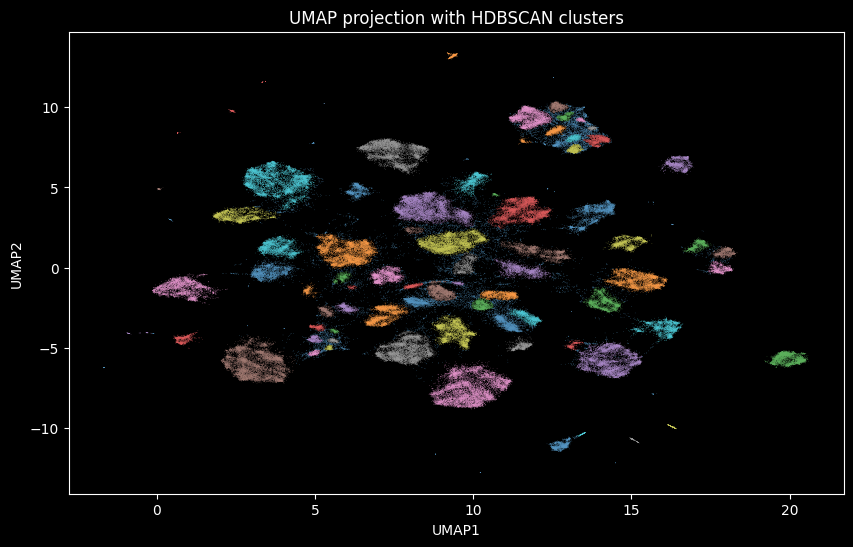

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=result_df, x='UMAP1', y='UMAP2', hue='Cluster', palette='tab10', s=0.1,
    legend=False)
plt.title('UMAP projection with HDBSCAN clusters')
plt.show()

## Explainability Model 2

In [12]:
X = pd.read_csv("/kaggle/input/snn-m3-data/Model2.3_Out/test_dfs0.csv")
X["customer_age"] = 0
y_pred = pd.read_csv("/kaggle/input/snn-m3-data/Model2.3_Out/predictions_run0.csv", header=None)
y_true = X["fraud_bool"]
X = X.drop("fraud_bool", axis=1)

In [13]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(X)

umap_model = umap.UMAP(n_neighbors=5, random_state=42, verbose=True)#, metric="correlation")
X_umap = umap_model.fit_transform(data_scaled)

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(n_jobs=1, n_neighbors=5, random_state=42, verbose=True)
Mon Apr 14 14:52:56 2025 Construct fuzzy simplicial set
Mon Apr 14 14:52:56 2025 Finding Nearest Neighbors
Mon Apr 14 14:52:56 2025 Building RP forest with 28 trees
Mon Apr 14 14:53:05 2025 NN descent for 18 iterations
	 1  /  18
	 2  /  18
	 3  /  18
	 4  /  18
	Stopping threshold met -- exiting after 4 iterations
Mon Apr 14 14:53:13 2025 Finished Nearest Neighbor Search
Mon Apr 14 14:53:13 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Apr 14 14:55:20 2025 Finished embedding


In [14]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=100)
clusters = clusterer.fit_predict(X_umap)

result_df = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2'])
result_df['Cluster'] = clusters
result_df['Prediction'] = y_pred.values.flatten()
result_df['Label'] = y_true.values.flatten()

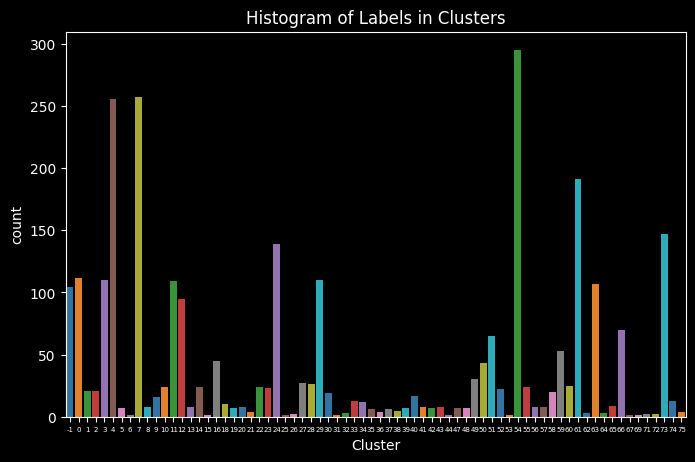

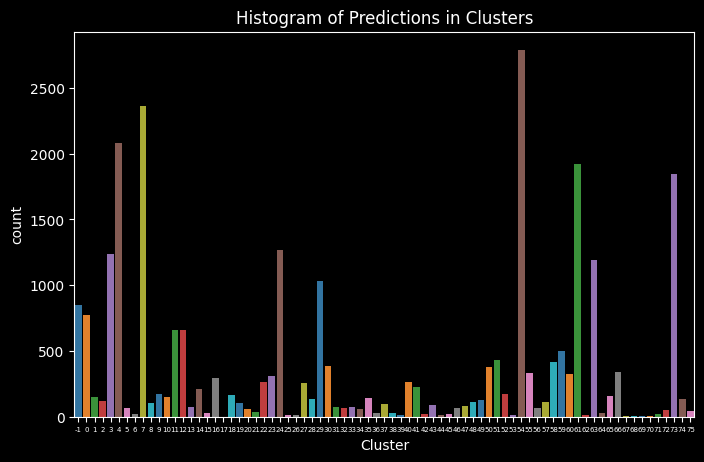

In [15]:
positive_preds = result_df[result_df['Label'] == 1]
plt.figure(figsize=(8, 5))
plt.xticks(fontsize=5)
sns.countplot(data=positive_preds, x='Cluster', palette='tab10')
plt.title('Histogram of Labels in Clusters')
plt.show()

positive_preds = result_df[result_df['Prediction'] == 1]
plt.figure(figsize=(8, 5))
plt.xticks(fontsize=5)
sns.countplot(data=positive_preds, x='Cluster', palette='tab10')
plt.title('Histogram of Predictions in Clusters')
plt.show()

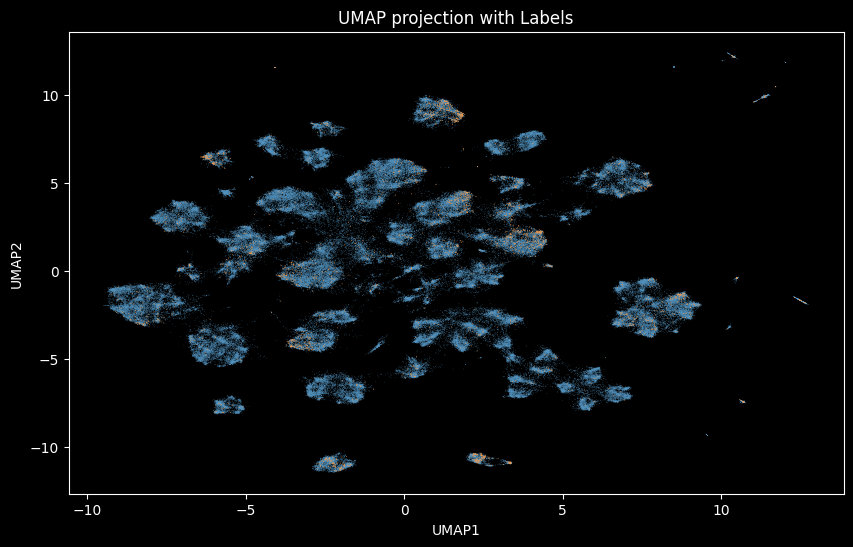

In [16]:
plt.figure(figsize=(10, 6))

palette = sns.color_palette('tab10', n_colors=result_df['Label'].nunique())
label_colors = {label: palette[i] for i, label in enumerate(sorted(result_df['Label'].unique()))}

sns.scatterplot(
    data=result_df[result_df['Label'] != 1],
    x='UMAP1', y='UMAP2',
    hue='Label',
    palette=label_colors,
    s=0.1,
    legend=False,
    zorder=1
)

sns.scatterplot(
    data=result_df[result_df['Label'] == 1],
    x='UMAP1', y='UMAP2',
    hue='Label',
    palette=label_colors,
    s=0.3,
    legend=False,
    zorder=2
)

plt.title('UMAP projection with Labels')
plt.show()

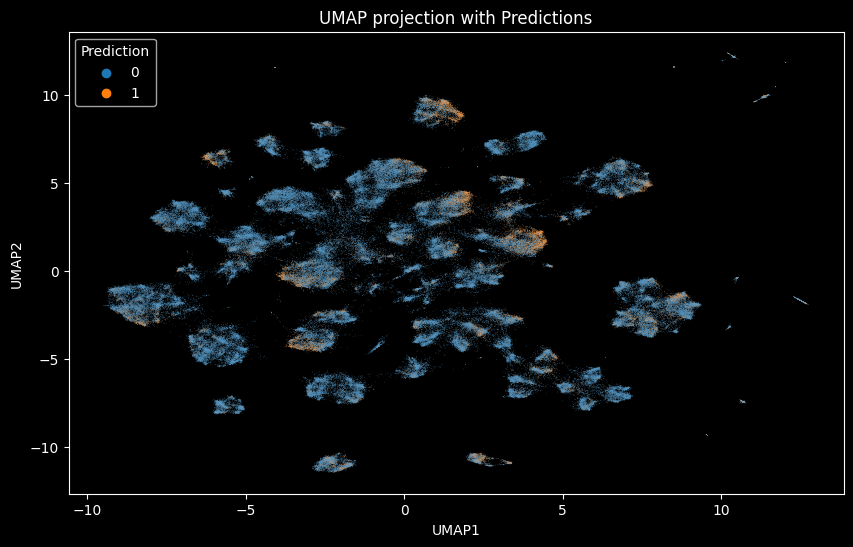

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=result_df, x='UMAP1', y='UMAP2', hue='Prediction', palette='tab10', s=0.1)
plt.title('UMAP projection with Predictions')
plt.show()

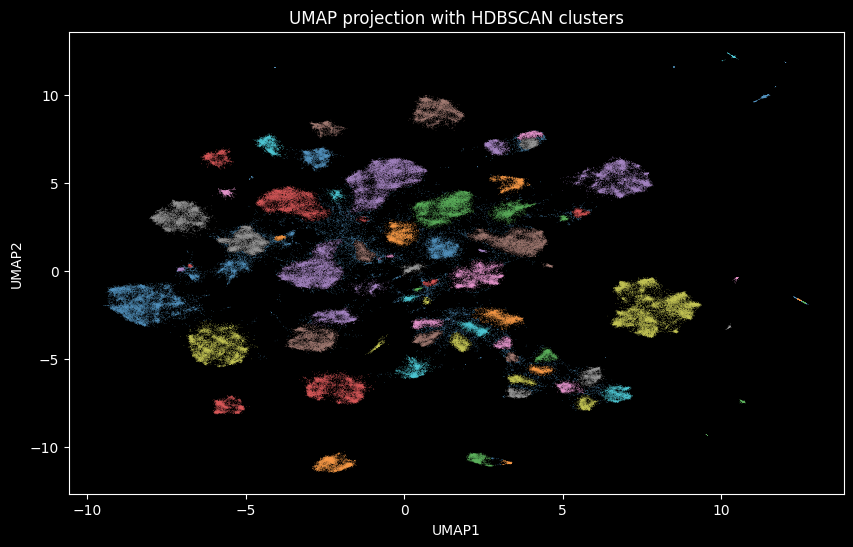

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=result_df, x='UMAP1', y='UMAP2', hue='Cluster', palette='tab10', s=0.1,
    legend=False)
plt.title('UMAP projection with HDBSCAN clusters')
plt.show()

## Explainability Model 3

In [19]:
X = pd.read_csv("/kaggle/input/snn-m3-data/Model3.2_Out/test_dfs0.csv")
X["customer_age"] = 0
y_pred = pd.read_csv("/kaggle/input/snn-m3-data/Model3.2_Out/predictions_run0.csv", header=None)
y_true = X["fraud_bool"]
X = X.drop("fraud_bool", axis=1)

In [20]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(X)

umap_model = umap.UMAP(n_neighbors=5, random_state=42, verbose=True)#, metric="correlation")
X_umap = umap_model.fit_transform(data_scaled)

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(n_jobs=1, n_neighbors=5, random_state=42, verbose=True)
Mon Apr 14 14:55:41 2025 Construct fuzzy simplicial set
Mon Apr 14 14:55:41 2025 Finding Nearest Neighbors
Mon Apr 14 14:55:41 2025 Building RP forest with 28 trees
Mon Apr 14 14:55:50 2025 NN descent for 18 iterations
	 1  /  18
	 2  /  18
	 3  /  18
	 4  /  18
	Stopping threshold met -- exiting after 4 iterations
Mon Apr 14 14:55:57 2025 Finished Nearest Neighbor Search
Mon Apr 14 14:55:58 2025 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Apr 14 14:58:05 2025 Finished embedding


In [21]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=100)
clusters = clusterer.fit_predict(X_umap)

result_df = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2'])
result_df['Cluster'] = clusters
result_df['Prediction'] = y_pred.values.flatten()
result_df['Label'] = y_true.values.flatten()

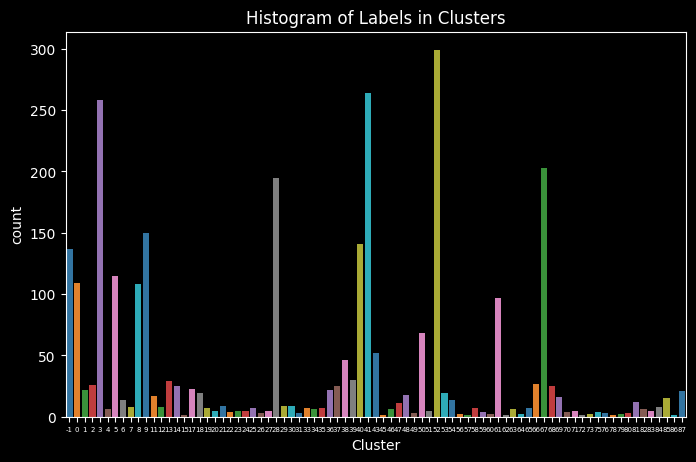

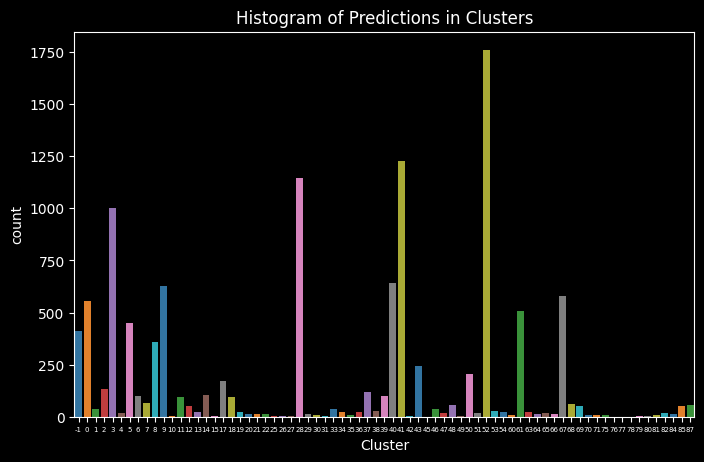

In [22]:
positive_preds = result_df[result_df['Label'] == 1]
plt.figure(figsize=(8, 5))
plt.xticks(fontsize=5)
sns.countplot(data=positive_preds, x='Cluster', palette='tab10')
plt.title('Histogram of Labels in Clusters')
plt.show()

positive_preds = result_df[result_df['Prediction'] == 1]
plt.figure(figsize=(8, 5))
plt.xticks(fontsize=5)
sns.countplot(data=positive_preds, x='Cluster', palette='tab10')
plt.title('Histogram of Predictions in Clusters')
plt.show()

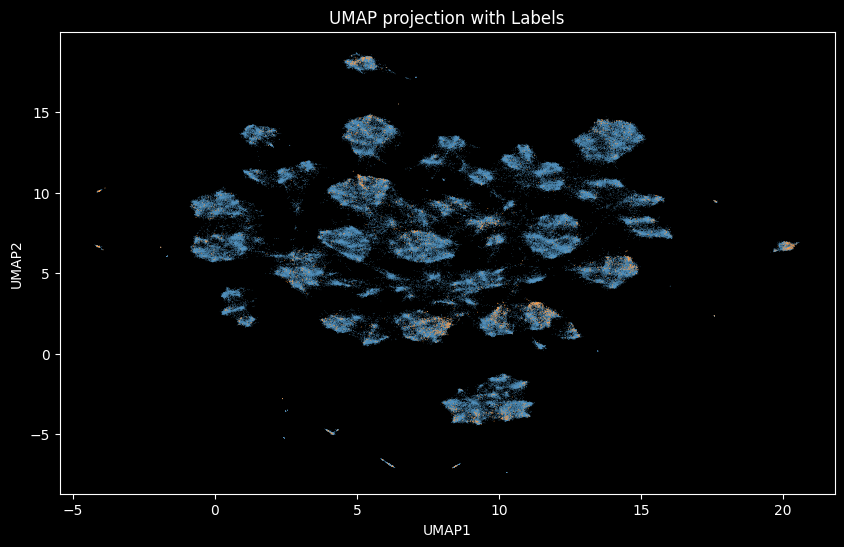

In [23]:
plt.figure(figsize=(10, 6))

palette = sns.color_palette('tab10', n_colors=result_df['Label'].nunique())
label_colors = {label: palette[i] for i, label in enumerate(sorted(result_df['Label'].unique()))}

sns.scatterplot(
    data=result_df[result_df['Label'] != 1],
    x='UMAP1', y='UMAP2',
    hue='Label',
    palette=label_colors,
    s=0.1,
    legend=False,
    zorder=1
)

sns.scatterplot(
    data=result_df[result_df['Label'] == 1],
    x='UMAP1', y='UMAP2',
    hue='Label',
    palette=label_colors,
    s=0.3,
    legend=False,
    zorder=2
)

plt.title('UMAP projection with Labels')
plt.show()

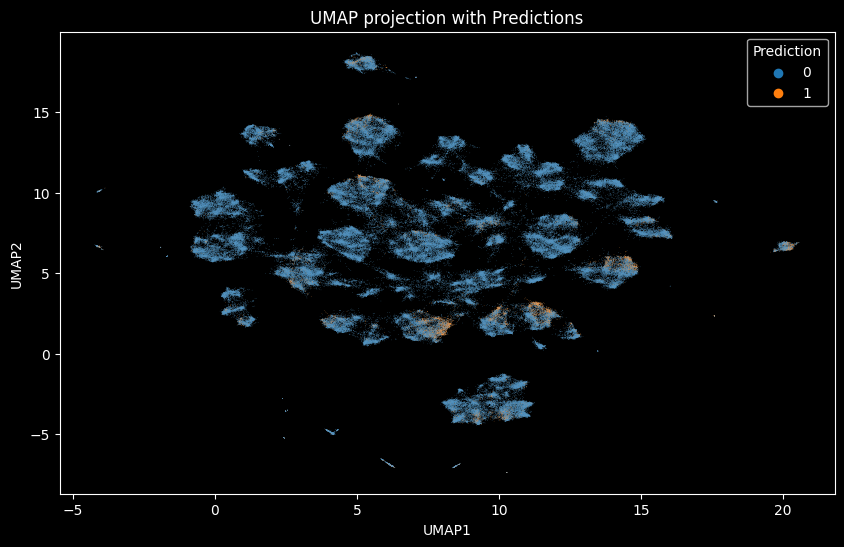

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=result_df, x='UMAP1', y='UMAP2', hue='Prediction', palette='tab10', s=0.1)
plt.title('UMAP projection with Predictions')
plt.show()

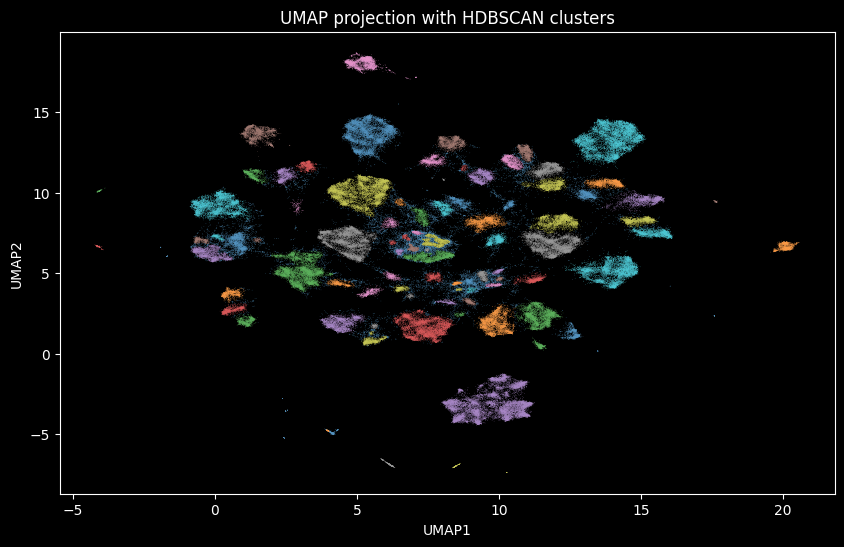

In [25]:
# Plot UMAP clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=result_df, x='UMAP1', y='UMAP2', hue='Cluster', palette='tab10', s=0.1,
    legend=False)
plt.title('UMAP projection with HDBSCAN clusters')
plt.show()